In [ ]:
!pip install numpy pandas scikit-learn

In [41]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
dataset = pd.read_csv("/content/dataset.csv")

In [12]:
dataset

,type,text
0,spam,"\t""For the most sparkling shopping breaks from..."
1,spam,\t07732584351 - Rodger Burns - MSG = We tried ...
2,spam,\t09066362231 URGENT! Your mobile No 07xxxxxxx...
3,spam,"\t44 7732584351, Do you want a New Nokia 3510i..."
4,spam,"\t449050000301 You have won a Â£2,000 price! T..."
...,...,...
7049,spam,sports fans - get the latest sports news str* ...
7050,spam,subscribe to weekly ringtone-get 1st week free...
7051,spam,thesmszone.com lets you send free anonymous an...
7052,spam,u r subscribed 2 TEXTCOMP 250 wkly comp. 1st w...


In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7054 entries, 0 to 7053
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    7054 non-null   object
 1   text    7054 non-null   object
dtypes: object(2)
memory usage: 110.3+ KB


In [14]:
dataset.drop_duplicates(inplace=True)

In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7054 entries, 0 to 7053
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    7054 non-null   object
 1   text    7054 non-null   object
dtypes: object(2)
memory usage: 110.3+ KB


In [16]:
dataset.type.unique()

array(['spam', 'ham'], dtype=object)

In [17]:
dataset.type.value_counts()

,count
type,
ham,5815
spam,1239


# Word Cloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


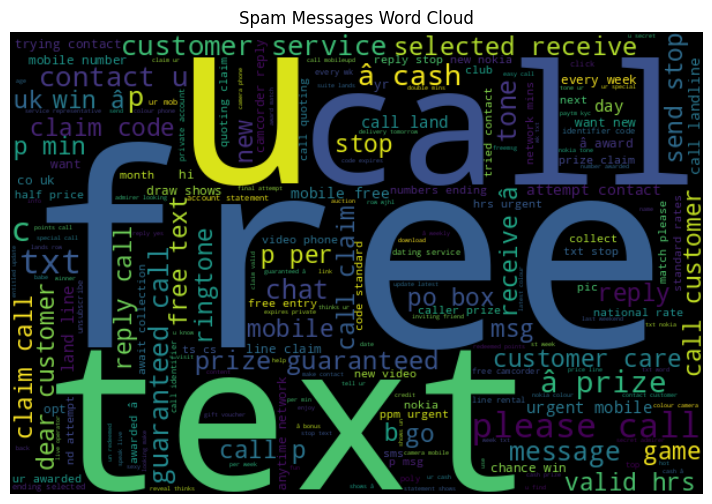

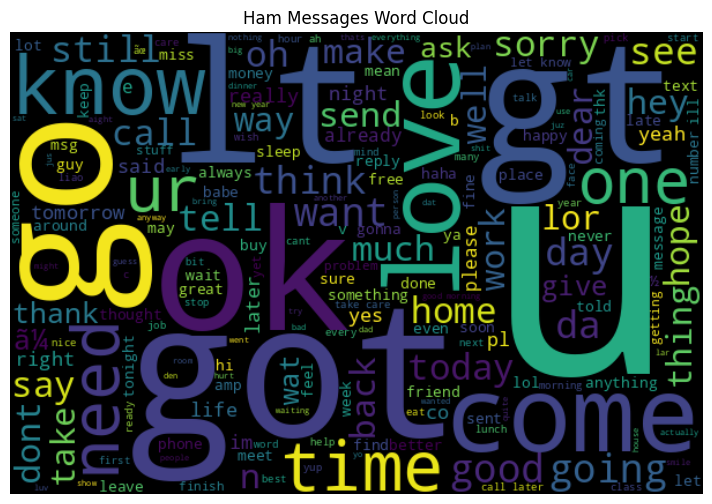

In [18]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))


def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"\W", " ", text)
    text = re.sub(r"\d+", "", text)
    text = text.lower()
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

dataset["clean_text"] = dataset["text"].astype(str).apply(clean_text)

spam_text = " ".join(dataset[dataset["type"] == "spam"]["clean_text"])
ham_text = " ".join(dataset[dataset["type"] == "ham"]["clean_text"])


plt.figure(figsize=(10, 6))
wordcloud_spam = WordCloud(width=600, height=400, background_color="black").generate(spam_text)
plt.imshow(wordcloud_spam, interpolation="bilinear")
plt.title("Spam Messages Word Cloud")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 6))
wordcloud_ham = WordCloud(width=600, height=400, background_color="black").generate(ham_text)
plt.imshow(wordcloud_ham, interpolation="bilinear")
plt.title("Ham Messages Word Cloud")
plt.axis("off")

plt.show()


# Exploratory Data Analysis

### Pre processing

In [19]:
dataset.replace({"Smishing": "spam",
                 "smishing": "spam",
                 "Spam": "spam"}, inplace=True)

In [20]:
dataset.type.unique()

array(['spam', 'ham'], dtype=object)

In [21]:
dataset.sample(5)

,type,text,clean_text
4390,ham,Okï¿½greatï¿½.,okï ½greatï ½
5556,ham,Watching tv lor. Nice one then i like lor.,watching tv lor nice one like lor
2030,ham,Happy birthday... Be happy ..keep smiling...,happy birthday happy keep smiling
2026,ham,Hanging out with my brother and his family,hanging brother family
2692,ham,"I dun thk i'll quit yet... Hmmm, can go jazz ?...",dun thk quit yet hmmm go jazz yogasana oso go ...


In [22]:
dataset.isna().sum()

,0
type,0
text,0
clean_text,0


### Removing tabs, converting to lower case

In [23]:
dataset["text"] = dataset["text"].str.strip().str.replace(r"\t", "", regex=True)

In [24]:
dataset["text"] = dataset["text"].str.lower()

In [25]:
dataset["text"] = dataset["text"].apply(lambda x: re.sub(f"[{string.punctuation}]", "", x))

### Variable encoding

In [26]:
dataset["label"] = dataset["type"].map({"spam": 1, "ham": 0})

In [27]:
dataset = dataset.drop(columns=["type"])

In [28]:
dataset.head(10)

,text,clean_text,label
0,for the most sparkling shopping breaks from 45...,sparkling shopping breaks per person call visit,1
1,07732584351 rodger burns msg we tried to ca...,rodger burns msg tried call reply sms free nok...,1
2,09066362231 urgent your mobile no 07xxxxxxxxx ...,urgent mobile xxxxxxxxx â bonus caller prize n...,1
3,44 7732584351 do you want a new nokia 3510i co...,want new nokia colour phone deliveredtomorrow ...,1
4,449050000301 you have won a â£2000 price to cl...,â price claim call,1
5,forwarded from 448712404000please call 0871240...,forwarded please call immediately urgent messa...,1
6,a link to your picture has been sent you can a...,link picture sent also use,1
7,a â£400 xmas reward is waiting for you our com...,â xmas reward waiting computer randomly picked...,1
8,as a valued customer i am pleased to advise yo...,valued customer pleased advise following recen...,1
9,as a valued customer i am pleased to advise yo...,valued customer pleased advise following recen...,1


### Feature Engineering

In [29]:
dataset["char_count"] = dataset["text"].apply(len)

In [30]:
dataset["word_count"] = dataset["text"].apply(lambda x: len(x.split()))

In [31]:
dataset["special_char_count"] = dataset["text"].apply(lambda x: sum(1 for char in x if char in "!@#$%^&*()"))

In [32]:
dataset["contains_url"] = dataset["text"].apply(lambda x: 1 if re.search(r"www.\S+", x) else 0)
dataset["num_count"] = dataset["text"].apply(lambda x: sum(1 for char in x if char.isdigit()))

In [33]:
dataset.label.value_counts()

,count
label,
0,5815
1,1239


In [36]:
dataset.drop("clean_text", inplace=True, axis=1)

In [37]:
dataset

,text,label,char_count,word_count,special_char_count,contains_url,num_count
0,for the most sparkling shopping breaks from 45...,1,104,16,0,1,13
1,07732584351 rodger burns msg we tried to ca...,1,167,29,0,0,22
2,09066362231 urgent your mobile no 07xxxxxxxxx ...,1,146,25,0,0,35
3,44 7732584351 do you want a new nokia 3510i co...,1,168,28,0,0,33
4,449050000301 you have won a â£2000 price to cl...,1,66,11,0,0,27
...,...,...,...,...,...,...,...
7049,sports fans get the latest sports news str 2 ...,1,145,27,0,1,23
7050,subscribe to weekly ringtoneget 1st week frees...,1,95,13,0,0,18
7051,thesmszonecom lets you send free anonymous and...,1,130,20,0,0,0
7052,u r subscribed 2 textcomp 250 wkly comp 1st wk...,1,149,22,0,0,26


<ipython-input-42-d18f90c004a7>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




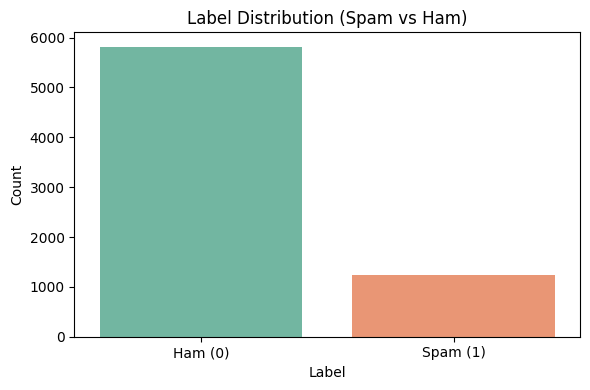

In [42]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=dataset, palette='Set2')
plt.title('Label Distribution (Spam vs Ham)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])
plt.tight_layout()
plt.show()

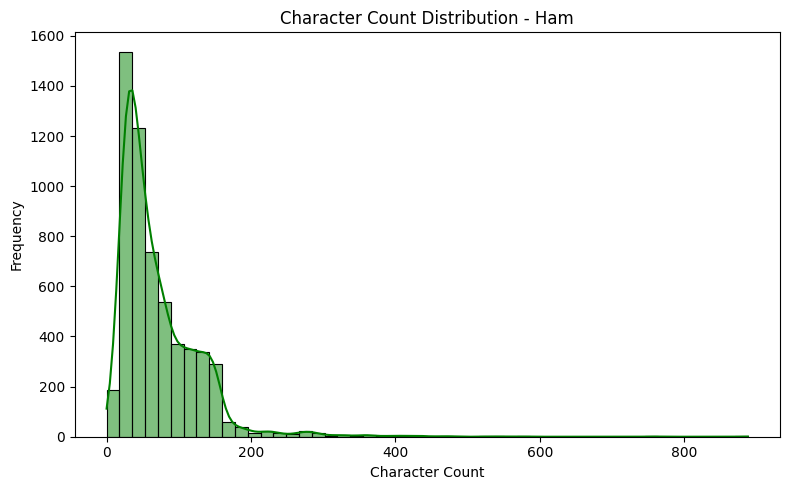

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(dataset[dataset['label'] == 0]['char_count'], bins=50, kde=True, color='green')
plt.title('Character Count Distribution - Ham')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

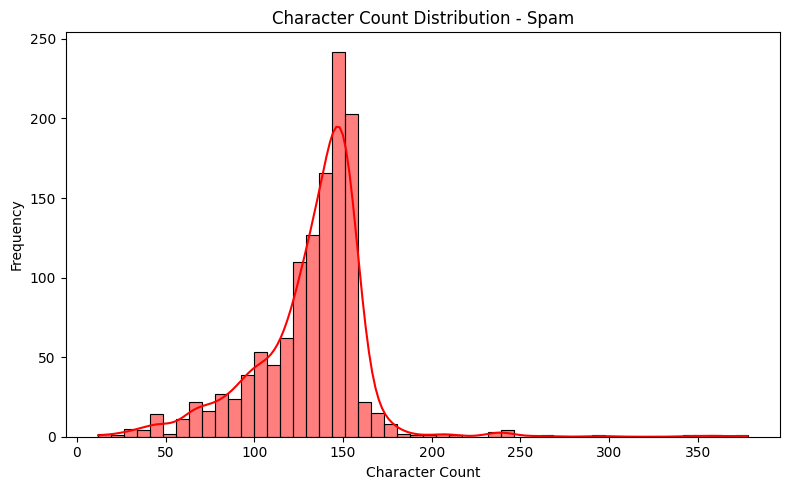

In [47]:
plt.figure(figsize=(8, 5))
sns.histplot(dataset[dataset['label'] == 1]['char_count'], bins=50, kde=True, color='red')
plt.title('Character Count Distribution - Spam')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

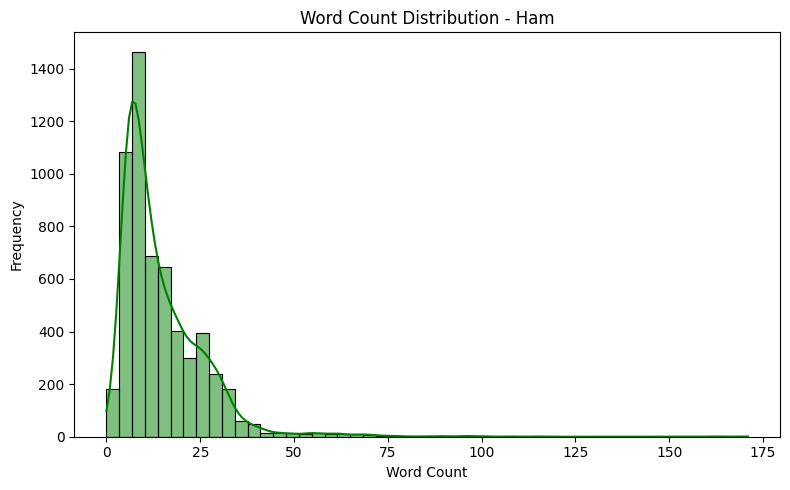

In [48]:
plt.figure(figsize=(8, 5))
sns.histplot(dataset[dataset['label'] == 0]['word_count'], bins=50, kde=True, color='green')
plt.title('Word Count Distribution - Ham')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

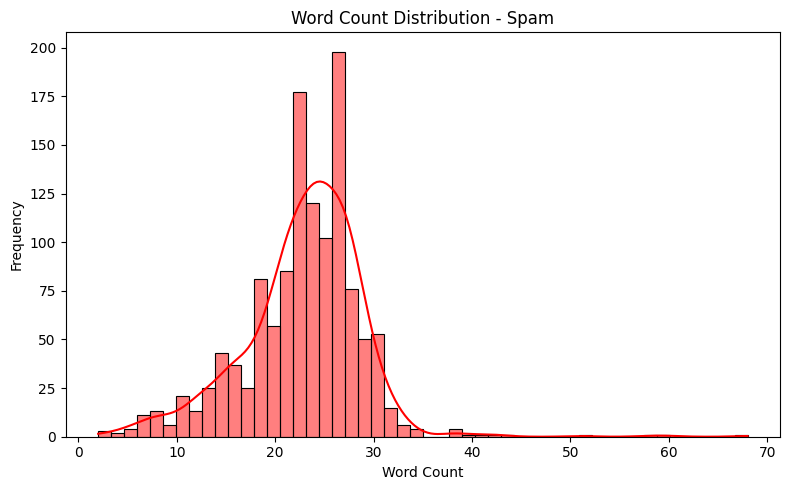

In [49]:
plt.figure(figsize=(8, 5))
sns.histplot(dataset[dataset['label'] == 1]['word_count'], bins=50, kde=True, color='red')
plt.title('Word Count Distribution - Spam')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

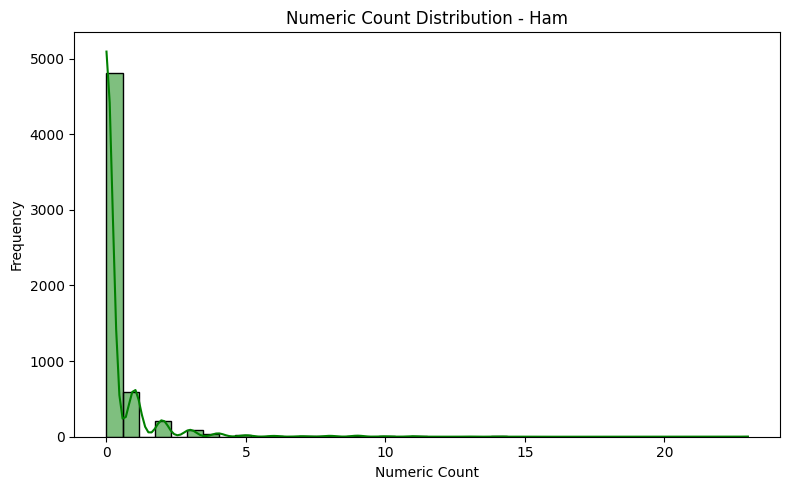

In [52]:
plt.figure(figsize=(8, 5))
sns.histplot(dataset[dataset['label'] == 0]['num_count'], bins=40, kde=True, color='green')
plt.title('Numeric Count Distribution - Ham')
plt.xlabel('Numeric Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

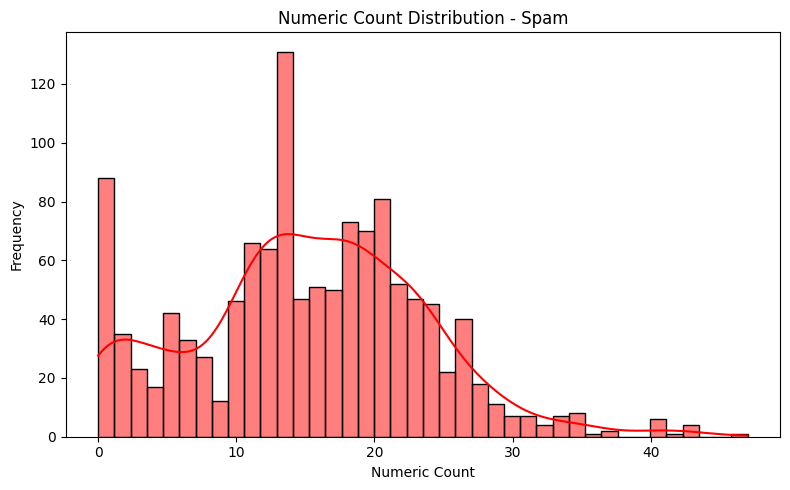

In [53]:
plt.figure(figsize=(8, 5))
sns.histplot(dataset[dataset['label'] == 1]['num_count'], bins=40, kde=True, color='red')
plt.title('Numeric Count Distribution - Spam')
plt.xlabel('Numeric Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

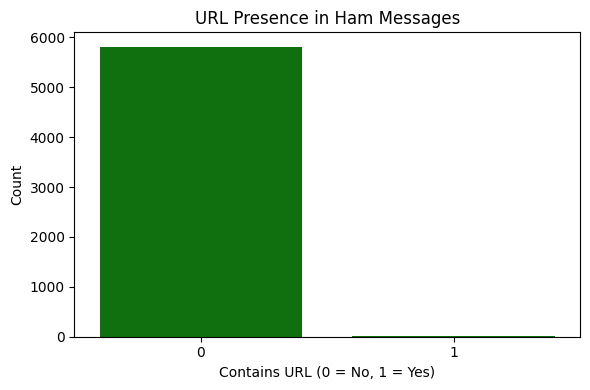

In [54]:
plt.figure(figsize=(6, 4))
sns.countplot(x=dataset[dataset['label'] == 0]['contains_url'], color='green')
plt.title('URL Presence in Ham Messages')
plt.xlabel('Contains URL (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

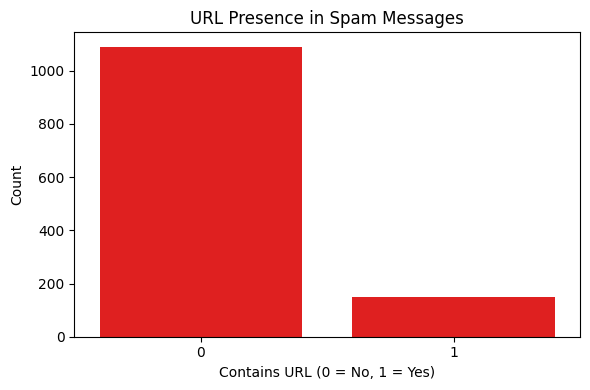

In [55]:
plt.figure(figsize=(6, 4))
sns.countplot(x=dataset[dataset['label'] == 1]['contains_url'], color='red')
plt.title('URL Presence in Spam Messages')
plt.xlabel('Contains URL (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<ipython-input-56-d6beb07168f4>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




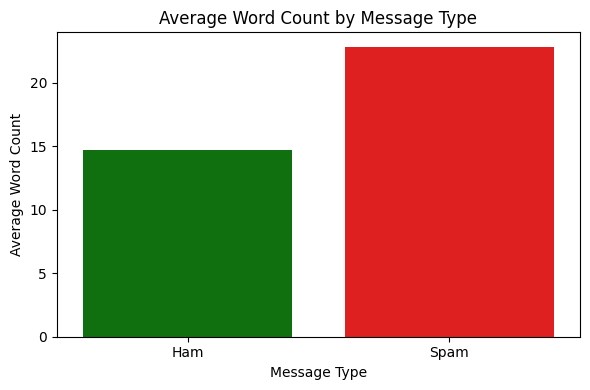

In [56]:
avg_word_count = dataset.groupby('label')['word_count'].mean().reset_index()
avg_word_count['label'] = avg_word_count['label'].map({0: 'Ham', 1: 'Spam'})

plt.figure(figsize=(6, 4))
sns.barplot(x='label', y='word_count', data=avg_word_count, palette=['green', 'red'])
plt.title('Average Word Count by Message Type')
plt.xlabel('Message Type')
plt.ylabel('Average Word Count')
plt.tight_layout()
plt.show()

<ipython-input-57-f108b9d4890e>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




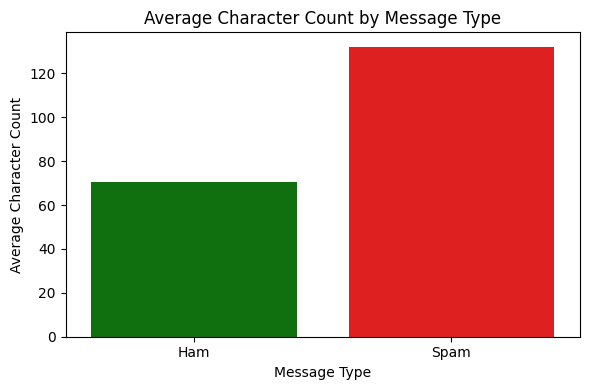

In [57]:
avg_char_count = dataset.groupby('label')['char_count'].mean().reset_index()
avg_char_count['label'] = avg_char_count['label'].map({0: 'Ham', 1: 'Spam'})

plt.figure(figsize=(6, 4))
sns.barplot(x='label', y='char_count', data=avg_char_count, palette=['green', 'red'])
plt.title('Average Character Count by Message Type')
plt.xlabel('Message Type')
plt.ylabel('Average Character Count')
plt.tight_layout()
plt.show()


<ipython-input-58-7011492787de>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




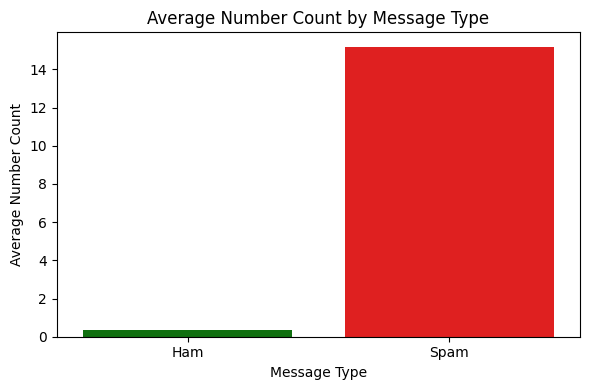

In [58]:
avg_num_count = dataset.groupby('label')['num_count'].mean().reset_index()
avg_num_count['label'] = avg_num_count['label'].map({0: 'Ham', 1: 'Spam'})

plt.figure(figsize=(6, 4))
sns.barplot(x='label', y='num_count', data=avg_num_count, palette=['green', 'red'])
plt.title('Average Number Count by Message Type')
plt.xlabel('Message Type')
plt.ylabel('Average Number Count')
plt.tight_layout()
plt.show()


<ipython-input-59-7b0ed3a0c5c5>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




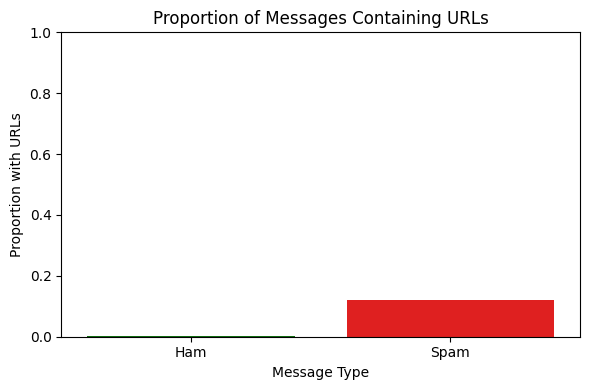

In [59]:
url_presence_ratio = dataset.groupby('label')['contains_url'].mean().reset_index()
url_presence_ratio['label'] = url_presence_ratio['label'].map({0: 'Ham', 1: 'Spam'})

plt.figure(figsize=(6, 4))
sns.barplot(x='label', y='contains_url', data=url_presence_ratio, palette=['green', 'red'])
plt.title('Proportion of Messages Containing URLs')
plt.xlabel('Message Type')
plt.ylabel('Proportion with URLs')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


<ipython-input-60-b41546804b9c>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




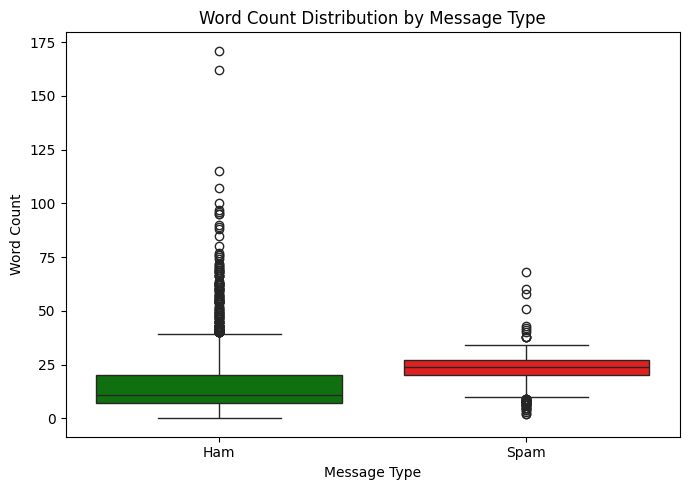

In [60]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='label', y='word_count', data=dataset, palette=['green', 'red'])
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.title('Word Count Distribution by Message Type')
plt.xlabel('Message Type')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()


In [ ]:
!pip install transformers datasets torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding


### using prompt engineering to use Distill-bert model

In [ ]:
def format_prompt(example):
    return {
        "text": f"### Instruction:\nClassify the message as 'spam' or 'ham'.\n\n"
                f"### Message:\n{example['text']}\n\n"
                f"### Features:\n"
                f"- Character Count: {example['char_count']}\n"
                f"- Word Count: {example['word_count']}\n"
                f"- Special Character Count: {example['special_char_count']}\n"
                f"- Contains URL: {example['contains_url']}\n"
                f"- Number Count: {example['num_count']}\n\n"
                f"### Response:\n"
    }

data = Dataset.from_pandas(dataset)

data = data.map(format_prompt)

data = data.train_test_split(test_size=0.1)
train_dataset = data["train"]
eval_dataset = data["test"]

Map:   0%|          | 0/7054 [00:00<?, ? examples/s]

In [ ]:
print(data)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'char_count', 'word_count', 'special_char_count', 'contains_url', 'num_count'],
        num_rows: 6348
    })
    test: Dataset({
        features: ['text', 'label', 'char_count', 'word_count', 'special_char_count', 'contains_url', 'num_count'],
        num_rows: 706
    })
})


In [ ]:
train_dataset[:3]

{'text': ["### Instruction:\nClassify the message as 'spam' or 'ham'.\n\n### Message:\nu mean its confirmed i tot they juz say oni ok then\n\n### Features:\n- Character Count: 51\n- Word Count: 12\n- Special Character Count: 0\n- Contains URL: 0\n- Number Count: 0\n\n### Response:\n",
  "### Instruction:\nClassify the message as 'spam' or 'ham'.\n\n### Message:\nim gonna be home soon and i dont want to talk about this stuff anymore tonight k its enough today\n\n### Features:\n- Character Count: 97\n- Word Count: 20\n- Special Character Count: 0\n- Contains URL: 0\n- Number Count: 0\n\n### Response:\n",
  "### Instruction:\nClassify the message as 'spam' or 'ham'.\n\n### Message:\nmm i am on the way to railway\n\n### Features:\n- Character Count: 29\n- Word Count: 8\n- Special Character Count: 0\n- Contains URL: 0\n- Number Count: 0\n\n### Response:\n"],
 'label': [0, 0, 0],
 'char_count': [51, 97, 29],
 'word_count': [12, 20, 8],
 'special_char_count': [0, 0, 0],
 'contains_url': [0, 0

In [ ]:
from pprint import pprint

pprint(train_dataset[0])

{'char_count': 51,
 'contains_url': 0,
 'label': 0,
 'num_count': 0,
 'special_char_count': 0,
 'text': '### Instruction:\n'
         "Classify the message as 'spam' or 'ham'.\n"
         '\n'
         '### Message:\n'
         'u mean its confirmed i tot they juz say oni ok then\n'
         '\n'
         '### Features:\n'
         '- Character Count: 51\n'
         '- Word Count: 12\n'
         '- Special Character Count: 0\n'
         '- Contains URL: 0\n'
         '- Number Count: 0\n'
         '\n'
         '### Response:\n',
 'word_count': 12}


### Using pre trained model, and using Auto Tokenization for the preferred model

In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
)

def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=512)

train_dataset = train_dataset.map(tokenize_function, batched=True)
eval_dataset = eval_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"]).with_format("torch")
eval_dataset = eval_dataset.remove_columns(["text"]).with_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/6348 [00:00<?, ? examples/s]

Map:   0%|          | 0/706 [00:00<?, ? examples/s]

### Start training using trainer function

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_sms_spam_finetuned",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-28-79bb7356a693>:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ankur3382 (ankur3382-student) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,No log,0.073898
2,0.080300,0.069033
3,0.025800,0.061486


TrainOutput(global_step=1191, training_loss=0.04640184401665086, metrics={'train_runtime': 979.1462, 'train_samples_per_second': 19.45, 'train_steps_per_second': 1.216, 'total_flos': 2522709140004864.0, 'train_loss': 0.04640184401665086, 'epoch': 3.0})

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.2 MB/s eta 0:00:00


In [ ]:
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

results = trainer.evaluate()
print("Evaluation Results:", results)

Evaluation Results: {'eval_loss': 0.06148616597056389, 'eval_runtime': 10.5015, 'eval_samples_per_second': 67.228, 'eval_steps_per_second': 4.285, 'epoch': 3.0}


In [ ]:
import evaluate

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    predictions = predictions.tolist()
    labels = labels.tolist()

    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision.compute(predictions=predictions, references=labels, average="binary")["precision"],
        "recall": recall.compute(predictions=predictions, references=labels, average="binary")["recall"],
        "f1": f1.compute(predictions=predictions, references=labels, average="binary")["f1"],
    }

results = trainer.evaluate()
predictions, labels, _ = trainer.predict(eval_dataset)


metrics = compute_metrics((predictions, labels))

print(f"📊 Model Evaluation Results:")
print(f"✅ Accuracy: {metrics['accuracy']:.4f}")
print(f"✅ Precision: {metrics['precision']:.4f}")
print(f"✅ Recall: {metrics['recall']:.4f}")
print(f"✅ F1-Score: {metrics['f1']:.4f}")


📊 Model Evaluation Results:
✅ Accuracy: 0.9901
✅ Precision: 0.9909
✅ Recall: 0.9478
✅ F1-Score: 0.9689


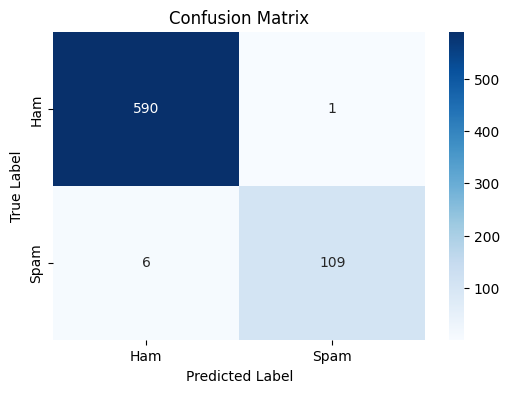


📄 Classification Report:
               precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       591
        Spam       0.99      0.95      0.97       115

    accuracy                           0.99       706
   macro avg       0.99      0.97      0.98       706
weighted avg       0.99      0.99      0.99       706



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


predictions = np.argmax(predictions, axis=-1)



conf_matrix = confusion_matrix(labels, predictions)


plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


class_report = classification_report(labels, predictions, target_names=["Ham", "Spam"])
print("\n📄 Classification Report:\n", class_report)


In [ ]:
print(predict_sms("let's meet today"))

Ham


In [ ]:
model = trainer.model
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
save_path = "/content/saved_distilbert_sms_spam"
trainer.save_model(save_path)

print(f"✅ Model saved at: {save_path}")

✅ Model saved at: /content/saved_distilbert_sms_spam


In [ ]:
import os

model_dir = "/content/saved_distilbert_sms_spam"
files = os.listdir(model_dir)
print("📂 Files in model directory:", files)

📂 Files in model directory: ['special_tokens_map.json', 'tokenizer_config.json', 'vocab.txt', 'training_args.bin', 'model.safetensors', 'tokenizer.json', 'config.json']


In [ ]:
from google.colab import files


files_to_download = [
    "config.json",
    "model.safetensors",
    "tokenizer.json",
    "special_tokens_map.json",
    "training_args.bin",
    "tokenizer_config.json",
    "vocab.txt"
]

model_dir = "/content/saved_distilbert_sms_spam"

for file_name in files_to_download:
    file_path = f"{model_dir}/{file_name}"
    files.download(file_path)
    print(f"✅ Downloaded: {file_name}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: tokenizer_config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: vocab.txt


In [ ]:
train_dataset

Dataset({
    features: ['label', 'char_count', 'word_count', 'special_char_count', 'contains_url', 'num_count', 'input_ids', 'attention_mask'],
    num_rows: 6348
})

In [ ]:
print(trainer.model.forward.__annotations__)

{'input_ids': typing.Optional[torch.Tensor], 'attention_mask': typing.Optional[torch.Tensor], 'head_mask': typing.Optional[torch.Tensor], 'inputs_embeds': typing.Optional[torch.Tensor], 'labels': typing.Optional[torch.LongTensor], 'output_attentions': typing.Optional[bool], 'output_hidden_states': typing.Optional[bool], 'return_dict': typing.Optional[bool], 'return': typing.Union[transformers.modeling_outputs.SequenceClassifierOutput, typing.Tuple[torch.Tensor, ...]]}


In [ ]:
print(trainer.tokenizer.model_input_names)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


['input_ids', 'attention_mask']


In [ ]:
print(trainer.train_dataset.column_names)

['label', 'char_count', 'word_count', 'special_char_count', 'contains_url', 'num_count', 'input_ids', 'attention_mask']


# Predicion task

In [61]:

def preprocess_text(text):
    text = text.strip()
    text = re.sub(r"\t", "", text)
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    return text

def predict_sms_with_features(text):

    cleaned_text = preprocess_text(text)


    char_count = len(cleaned_text)
    word_count = len(cleaned_text.split())
    special_char_count = sum([1 for char in cleaned_text if not char.isalnum() and not char.isspace()])
    contains_url = 1 if "http" in text or "www" in text else 0
    num_count = sum([1 for char in cleaned_text if char.isdigit()])


    formatted_prompt = f"""### Instruction:
Classify the message as 'spam' or 'ham'.

### Message:
{cleaned_text}

### Features:
- Character Count: {char_count}
- Word Count: {word_count}
- Special Character Count: {special_char_count}
- Contains URL: {contains_url}
- Number Count: {num_count}

### Response:
"""


    inputs = tokenizer(formatted_prompt, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=-1).item()

    return "Spam" if prediction == 1 else "Ham"
